In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TASK_DIR = Path.cwd().parent
INPUT_DIR = TASK_DIR / "input"
OUTPUT_DIR = TASK_DIR / "output"

CANONICAL_PATH = INPUT_DIR / "canonical_trajectory_stats.csv"
YEARWISE_PATH = INPUT_DIR / "yearwise_productivity_stats.csv"
LOG_DELTA_PATH = INPUT_DIR / "yearwise_log_delta_stats.csv"
YEAR_MAX_PATH = INPUT_DIR / "year_of_maximum.csv"
CUM_Y5_PATH = INPUT_DIR / "cumulative_through_year5.csv"
KS_PATH = INPUT_DIR / "ks_diagnostics.csv"
LAPLACE_PATH = INPUT_DIR / "stage_raw_increment_laplace.csv"
LAPLACE_VALUES_PATH = INPUT_DIR / "stage_raw_increment_values.csv"
AGGREGATE_PATH = INPUT_DIR / "aggregate_productivity_values.csv"
LOGNORMAL_FIT_PATH = INPUT_DIR / "lognormal_fit_stats.csv"
QQ_PATH = INPUT_DIR / "lognormal_qq_coordinates.csv"
RANK_CORR_PATH = INPUT_DIR / "rank_correlations.csv"
RANK_DECILE_PATH = INPUT_DIR / "rank_decile_transitions.csv"
RANK_CHANGE_PATH = INPUT_DIR / "rank_change_matrices.npz"
WASSERSTEIN_PATH = INPUT_DIR / "wasserstein_by_year.csv"
INEQUALITY_PATH = INPUT_DIR / "inequality_summary.csv"
DX_MANIFEST_PATH = INPUT_DIR / "diagnose_manifest.json"
STAGE_PARAMS_PATH = INPUT_DIR / "stage_grw_params.csv"

MODEL_NAME = "AR(1)-GRW-S"
MODEL_TAG = "stagewise_ar1_grw"
Y = 20
YEARS = np.arange(Y + 1)

palette = ["#0072B2", "#D55E00","#006D4E","#6A3D9A","#9E2F50"]

EMP_COLOR = palette[3]
SIM_COLOR = palette[1]

trajectory_stage_spans = [(0, 0, "0.70", "Year 0"),(1, 4, "0.78", "Years 1-4"),(5, 7, "0.86", "Years 5-7"),(8, 20, "0.93", "Years 8-20")]

transition_stage_spans = [(1, 4, "0.78", "Years 1-4"),(5, 7, "0.86", "Years 5-7"),(8, 20, "0.93", "Years 8-20")]

stage_order = ["years_1_4","years_5_7","years_8_20"]

stage_titles = {"years_1_4": "B. years 1-4","years_5_7": "C. years 5-7","years_8_20": "D. years 8-20"}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.facecolor": "white","axes.facecolor": "white","savefig.facecolor": "white","font.size": 10,"axes.titlesize": 11,"axes.labelsize": 10,"legend.fontsize": 9})

Task directory: /Users/samlunemagid/Desktop/mean_reversion_repo/plot
Output directory: /Users/samlunemagid/Desktop/mean_reversion_repo/plot/output


In [ ]:
required_paths = [
    CANONICAL_PATH,
    YEARWISE_PATH,
    LOG_DELTA_PATH,
    YEAR_MAX_PATH,
    CUM_Y5_PATH,
    KS_PATH,
    LAPLACE_PATH,
    LAPLACE_VALUES_PATH,
    AGGREGATE_PATH,
    LOGNORMAL_FIT_PATH,
    QQ_PATH,
    RANK_CORR_PATH,
    RANK_DECILE_PATH,
    RANK_CHANGE_PATH,
    WASSERSTEIN_PATH,
    STAGE_PARAMS_PATH]

canonical = pd.read_csv(CANONICAL_PATH)
yearwise = pd.read_csv(YEARWISE_PATH)
log_delta = pd.read_csv(LOG_DELTA_PATH)
year_max = pd.read_csv(YEAR_MAX_PATH)
cum_y5 = pd.read_csv(CUM_Y5_PATH)
ks_diagnostics = pd.read_csv(KS_PATH)
laplace = pd.read_csv(LAPLACE_PATH)
laplace_values = pd.read_csv(LAPLACE_VALUES_PATH)
aggregate = pd.read_csv(AGGREGATE_PATH)
lognormal_fit = pd.read_csv(LOGNORMAL_FIT_PATH)
qq = pd.read_csv(QQ_PATH)
rank_corr = pd.read_csv(RANK_CORR_PATH)
rank_decile = pd.read_csv(RANK_DECILE_PATH)
rank_change = np.load(RANK_CHANGE_PATH)
wasserstein = pd.read_csv(WASSERSTEIN_PATH)
inequality = pd.read_csv(INEQUALITY_PATH)
stage_params = pd.read_csv(STAGE_PARAMS_PATH)

print(f"Model: {MODEL_NAME}")
display(stage_params[["stage","start","end","beta","lognormal_mu","lognormal_sigma"]])

Model: AR(1)-GRW-S


,stage,start,end,beta,lognormal_mu,lognormal_sigma
0,years_1_4,1,4,0.451436,0.857612,0.983639
1,years_5_7,5,7,0.536658,0.742392,0.911151
2,years_8_20,8,20,0.600853,0.531023,0.903748


In [ ]:

def save_figure(fig, stem):
    fig.savefig(OUTPUT_DIR / f"{MODEL_TAG}_{stem}.png",dpi=300,bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{MODEL_TAG}_{stem}.pdf",bbox_inches="tight")
    plt.show()
    plt.close(fig)


def shade_stages(ax, spans):
    for start, end, shade, label in spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)


def finish_line_axis(ax, xlabel, ylabel, title=None):
    if title is not None:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)


def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)* np.exp(-np.abs(x - mu) / alpha))


def ks_value(name, column):
    return float(ks_diagnostics.loc[ks_diagnostics["diagnostic"].eq(name),column].iloc[0])

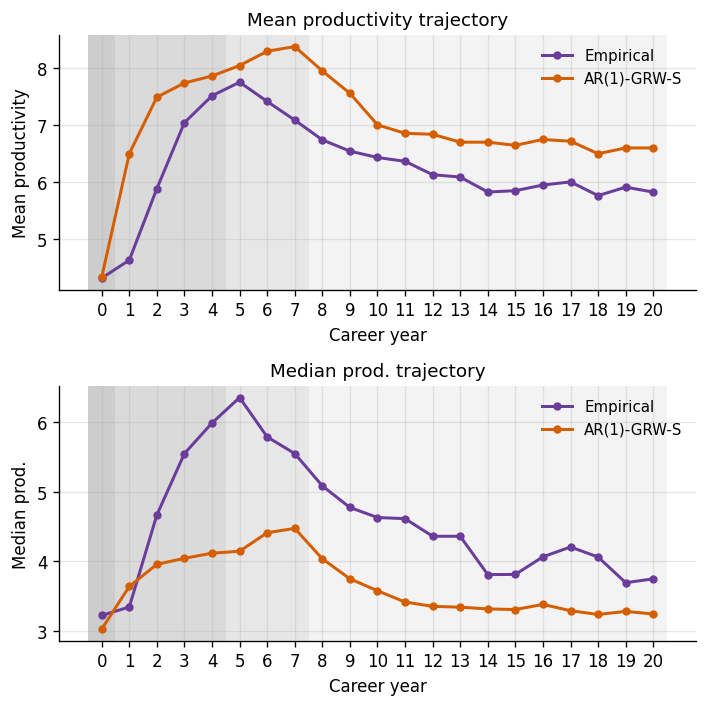

In [42]:
fig, axes = plt.subplots(2,1,figsize=(6, 6))

for ax in axes:
    shade_stages(ax,trajectory_stage_spans)

for source, color, label in [("empirical", EMP_COLOR, "Empirical"),("simulated", SIM_COLOR, MODEL_NAME)]:
    subset = (canonical.loc[canonical["source"].eq(source)].sort_values("career_age"))

    axes[0].plot(subset["career_age"],subset["mean"],marker="o",color=color,linewidth=1.8,markersize=4,label=label,zorder=3)

    axes[1].plot(subset["career_age"],subset["median"],marker="o",color=color,linewidth=1.8,markersize=4,label=label,zorder=3)

finish_line_axis(axes[0],"Career year","Mean productivity","Mean productivity trajectory")

finish_line_axis(axes[1],"Career year","Median prod.","Median prod. trajectory")

for ax in axes:
    ax.set_xticks(YEARS)
    ax.legend(frameon=False)

fig.tight_layout()

save_figure(fig,"prodSpaceMeanVsMedian")

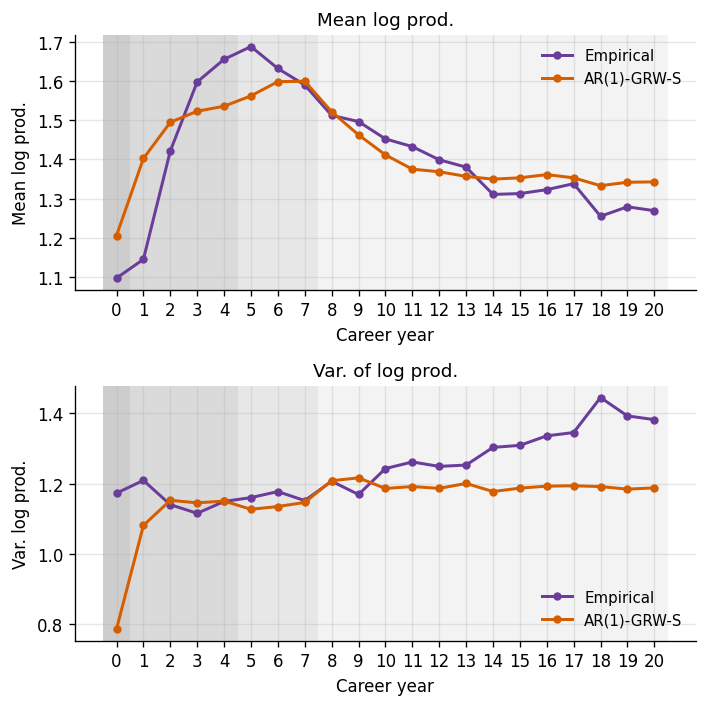

In [43]:
fig, axes = plt.subplots(2,1,figsize=(6, 6))

for ax in axes:
    shade_stages(ax,trajectory_stage_spans)

for source, color, label in [("empirical", EMP_COLOR, "Empirical"),("simulated", SIM_COLOR, MODEL_NAME)]:
    subset = (yearwise.loc[yearwise["source"].eq(source)].sort_values("career_age"))

    axes[0].plot(subset["career_age"],subset["mean_log_prod"],marker="o",color=color,linewidth=1.8,markersize=4,label=label,zorder=3)

    axes[1].plot(subset["career_age"],subset["var_log_prod"],marker="o",color=color,linewidth=1.8,markersize=4,label=label,zorder=3)

finish_line_axis(axes[0],"Career year","Mean log prod.","Mean log prod.")

finish_line_axis(axes[1],"Career year","Var. log prod.","Var. of log prod.")

for ax in axes:
    ax.set_xticks(YEARS)
    ax.legend(frameon=False)

fig.tight_layout()

save_figure(fig,"logCompare")

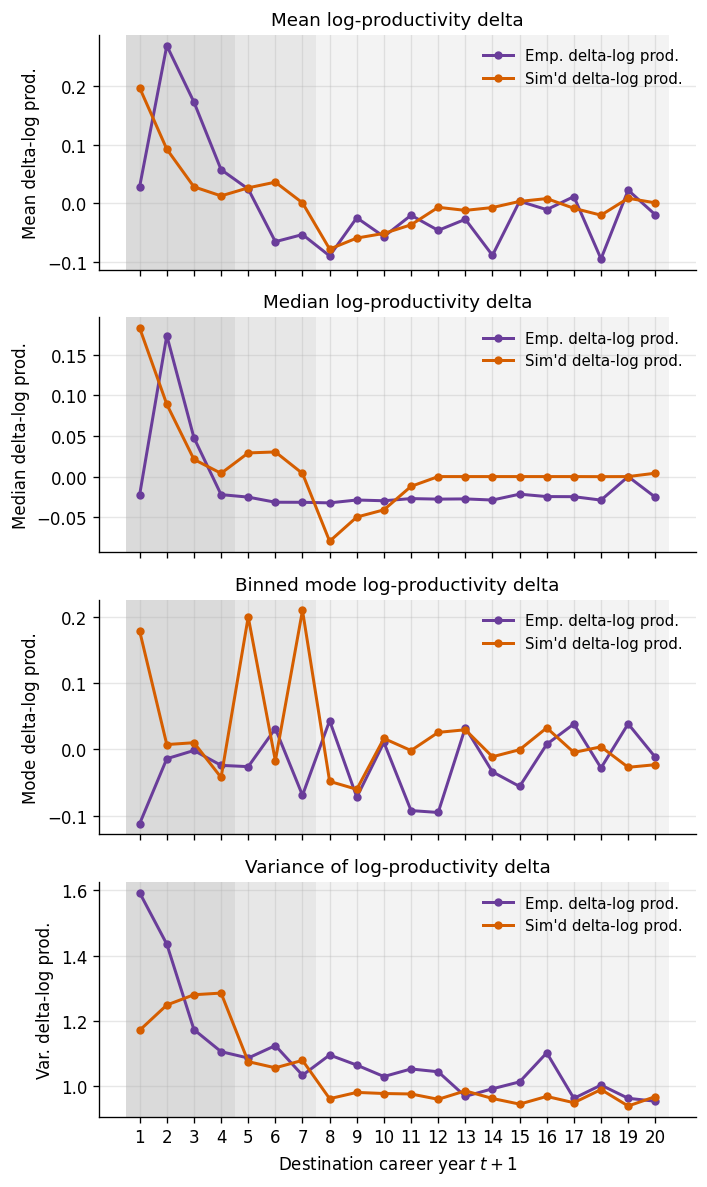

In [44]:
fig, axes = plt.subplots(4,1,figsize=(6, 10),sharex=True)

for ax in axes:
    shade_stages(ax,transition_stage_spans)

moment_specs = [
    ("mean_log_delta",
    "Mean log-productivity delta",
    "Mean delta-log prod."),
    ("median_log_delta",
    "Median log-productivity delta",
    "Median delta-log prod."),
    ("mode_log_delta",
    "Binned mode log-productivity delta",
    "Mode delta-log prod."),
    ("var_log_delta",
    "Variance of log-productivity delta",
    "Var. delta-log prod.")]

for ax, (column, title, ylabel) in zip(axes,moment_specs):
    for source, color, label in [("empirical", EMP_COLOR, "Emp. delta-log prod."),("simulated", SIM_COLOR, "Sim'd delta-log prod.")]:
        subset = (log_delta.loc[log_delta["source"].eq(source)].sort_values("destination_year"))

        ax.plot(subset["destination_year"],subset[column],marker="o",color=color,linewidth=1.8,markersize=4,label=label,zorder=3)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

axes[-1].set_xlabel("Destination career year $t+1$")
axes[-1].set_xticks(np.arange(1, Y + 1))

fig.tight_layout()

save_figure(fig,"logDeltaMoments")

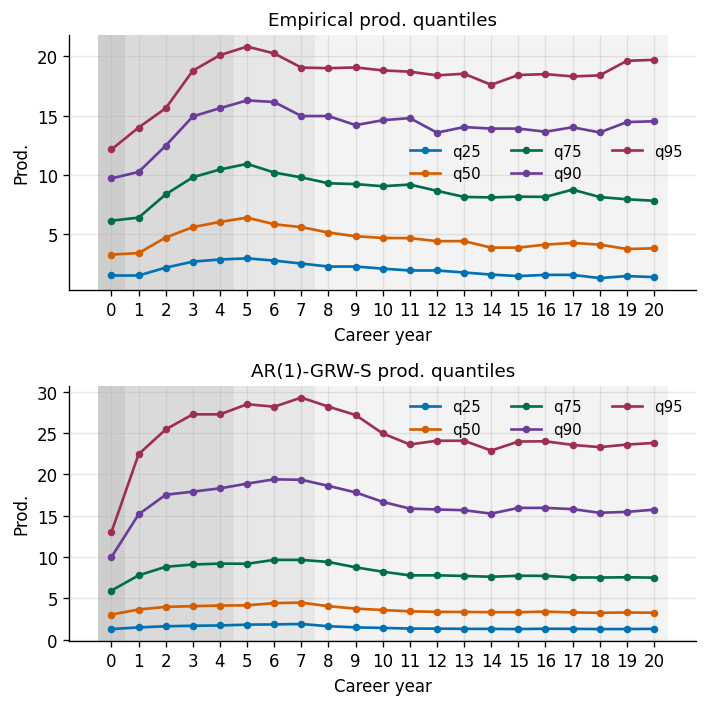

In [45]:
qcols = ["q25_prod","q50_prod","q75_prod","q90_prod","q95_prod"]

quantile_colors = palette

fig, axes = plt.subplots(2,1,figsize=(6, 6))

for ax in axes:
    shade_stages(ax,trajectory_stage_spans)

for ax, source, title in [(axes[0], "empirical", "Empirical prod. quantiles"),(axes[1], "simulated", f"{MODEL_NAME} prod. quantiles")]:
    subset = (yearwise.loc[yearwise["source"].eq(source)].sort_values("career_age"))

    for qcol, color in zip(qcols,quantile_colors):
        ax.plot(subset["career_age"],subset[qcol],marker="o",color=color,linewidth=1.6,markersize=3.5,label=qcol.replace("_prod", ""),zorder=3)

    finish_line_axis(ax,"Career year","Prod.",title)
    ax.set_xticks(YEARS)
    ax.legend(frameon=False,ncol=3)

fig.tight_layout()

save_figure(fig,"quantiles")

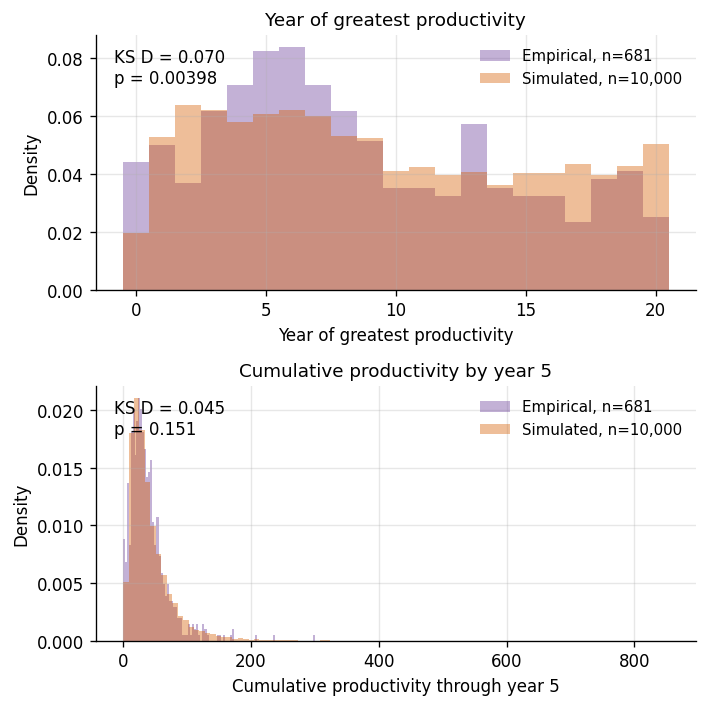

In [46]:
fig, axes = plt.subplots(2,1,figsize=(6, 6))

for source, color, label in [("empirical", EMP_COLOR, "Empirical"),("simulated", SIM_COLOR, "Simulated")]:
    values = year_max.loc[year_max["source"].eq(source),"year_of_maximum"]

    axes[0].hist(values,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.40,density=True,color=color,label=f"{label}, n={len(values):,}")

    values = cum_y5.loc[cum_y5["source"].eq(source),"cumulative_productivity"]

    axes[1].hist(values,bins=100,alpha=0.40,density=True,color=color,label=f"{label}, n={len(values):,}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend(frameon=False)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.3)

axes[0].text(0.03,0.95,(f"KS D = {ks_value('year_of_maximum', 'statistic'):.3f}\n"f"p = {ks_value('year_of_maximum', 'pvalue'):.3g}"),transform=axes[0].transAxes,va="top")

axes[1].text(0.03,0.95,(f"KS D = {ks_value('cumulative_through_year5', 'statistic'):.3f}\n"f"p = {ks_value('cumulative_through_year5', 'pvalue'):.3g}"),transform=axes[1].transAxes,va="top")

fig.tight_layout()

save_figure(fig,"compareDistribs")

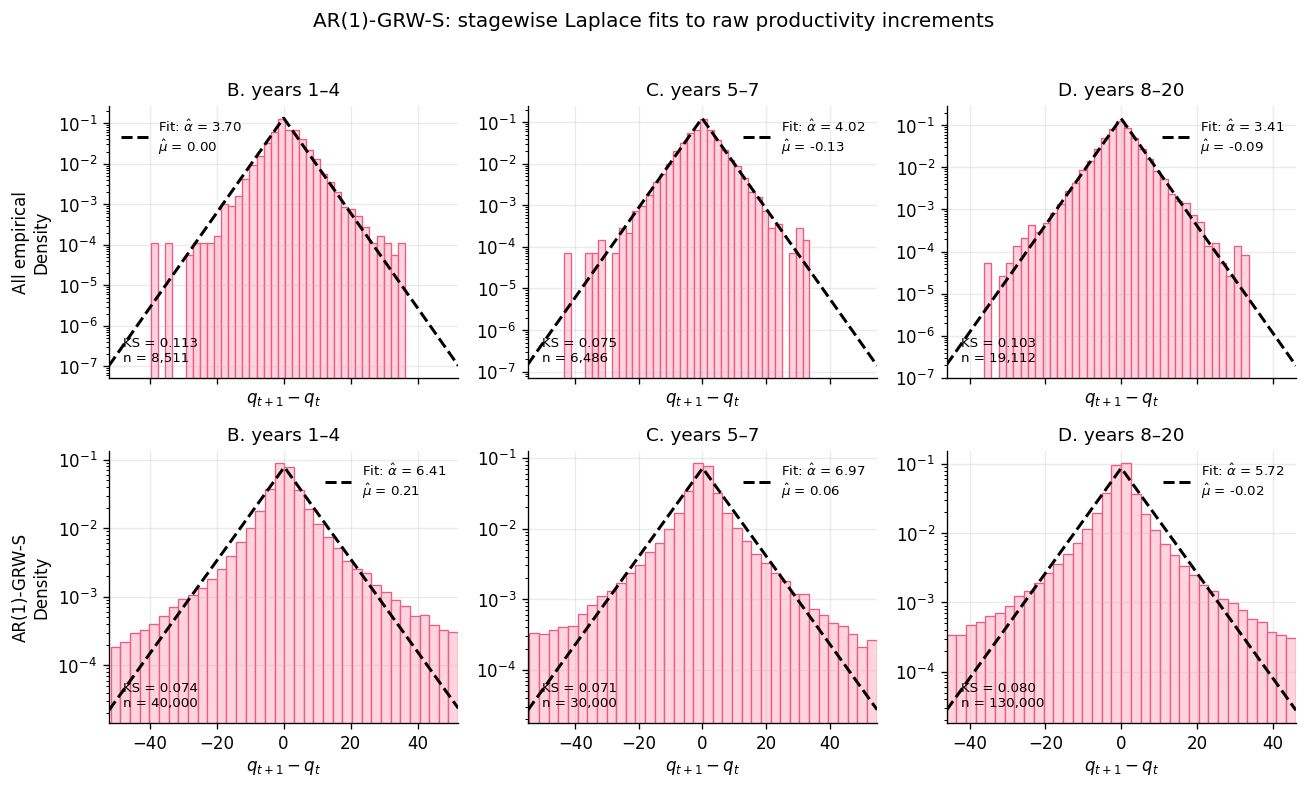

In [47]:
xlims = {}

for stage in stage_order:
    pooled = laplace_values.loc[laplace_values["stage"].eq(stage),"value"].dropna().to_numpy()

    lo, hi = np.quantile(pooled,[0.005, 0.995])

    limit = max(abs(lo),abs(hi),1)

    xlims[stage] = (-limit,limit)

fig, axes = plt.subplots(2,3,figsize=(11, 6.4),sharex="col",sharey=False)

for row, (source, source_name) in enumerate([("empirical", "All empirical"),("simulated", MODEL_NAME)]):
    for col, stage in enumerate(stage_order):
        ax = axes[row, col]

        values = laplace_values.loc[laplace_values["source"].eq(source) & laplace_values["stage"].eq(stage),"value"].dropna().to_numpy()

        fit = laplace.loc[laplace["source"].eq(source) & laplace["stage"].eq(stage)].iloc[0]

        mu = float(fit["mu_hat"])
        alpha = float(fit["alpha_hat"])
        ks = float(fit["ks_stat"])
        n = int(fit["n"])

        lo, hi = xlims[stage]
        clipped = values[(values >= lo) & (values <= hi)]

        ax.hist(clipped,bins=36,density=True,color="#ffd4df",edgecolor="#f05a87",linewidth=0.8)

        xx = np.linspace(lo,hi,600)

        ax.plot(xx,laplace_pdf(xx,mu,alpha),linestyle="--",color="black", linewidth=1.8,label=(rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}"))

        ax.set_yscale("log")
        ax.set_xlim(lo, hi)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False,fontsize=8)
        ax.set_title(stage_titles[stage])
        ax.set_xlabel(r"$q_{t+1} - q_t$")

        if col == 0:
            ax.set_ylabel(f"{source_name}\nDensity")

        ax.text(0.04,0.06,f"KS = {ks:.3f}\nn = {n:,}",transform=ax.transAxes,fontsize=8)

fig.suptitle(f"{MODEL_NAME}: stagewise Laplace fits to raw productivity increments", y=1.02)
fig.tight_layout()

save_figure(fig,"stageRawIncrementLaplace")

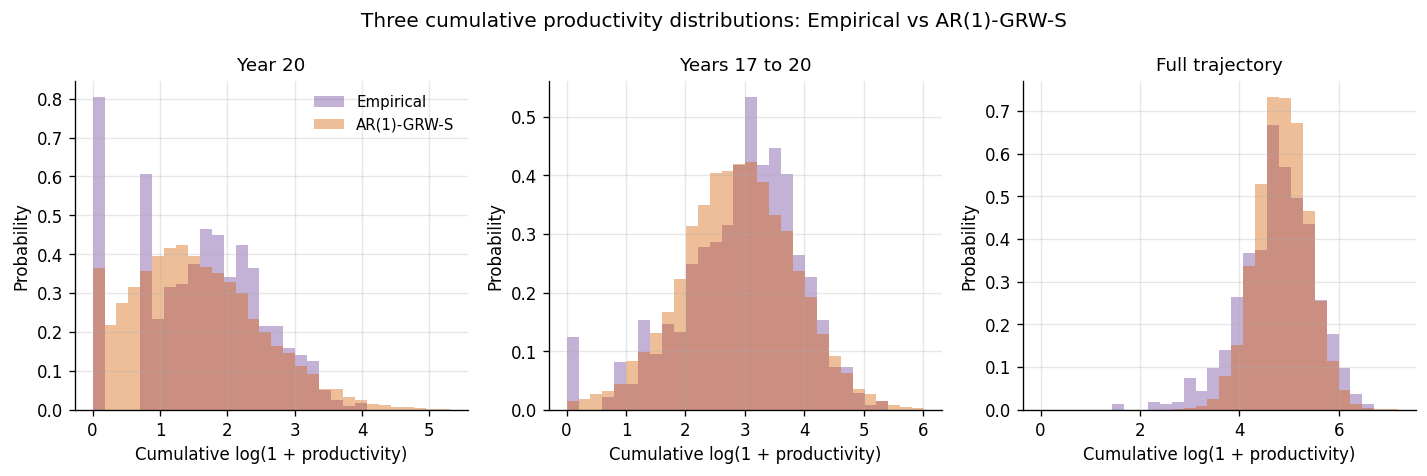

In [48]:
aggregation_order = [("year_20", "Year 20"),("years_17_20", "Years 17 to 20"),("full_career", "Full trajectory")]

fig, axes = plt.subplots(1,3,figsize=(12, 4))

for ax, (aggregation, title) in zip(axes,aggregation_order):
    subset = aggregate.loc[aggregate["aggregation"].eq(aggregation)]

    emp_values = subset.loc[subset["source"].eq("empirical"),"value"].to_numpy()

    sim_values = subset.loc[subset["source"].eq("simulated"),"value"].to_numpy()

    bins = np.histogram_bin_edges(np.log1p(np.concatenate([[0],emp_values,sim_values])), bins=30)

    ax.hist(np.log1p(emp_values),bins=bins,alpha=0.40,color=EMP_COLOR,label="Empirical",density=True)

    ax.hist(np.log1p(sim_values),bins=bins,alpha=0.40,color=SIM_COLOR,label=MODEL_NAME,density=True)

    ax.set_xlabel("Cumulative log(1 + productivity)")
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].legend(frameon=False)

fig.suptitle(f"Three cumulative productivity distributions: Empirical vs {MODEL_NAME}")
fig.tight_layout()

save_figure(fig,"threecumdists")

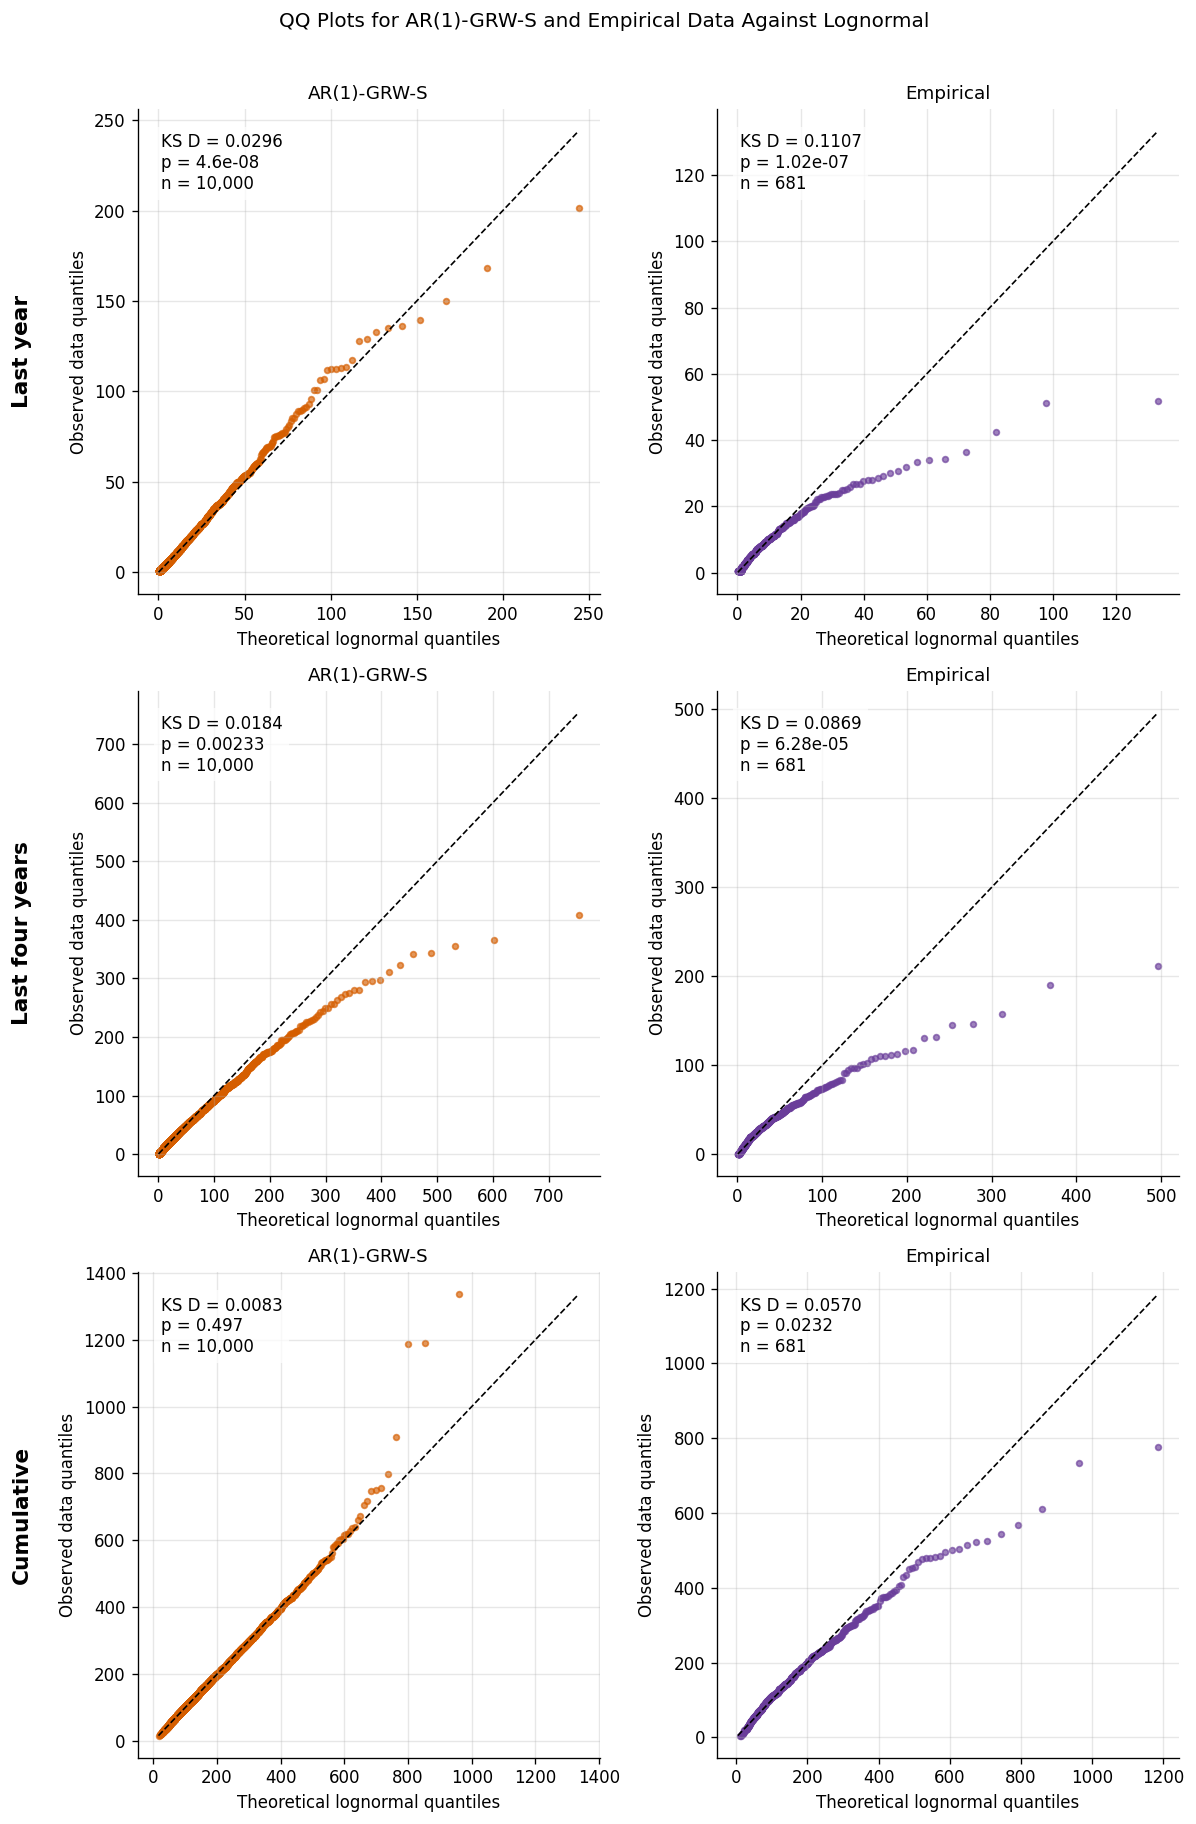

In [49]:
qq_rows = [("year_20", "Last year"),("years_17_20", "Last four years"),("full_career", "Cumulative")]

fig, axes = plt.subplots(3,2,figsize=(10, 15))

for row, (aggregation, row_title) in enumerate(qq_rows):
    for col, (source, title) in enumerate([("simulated", MODEL_NAME),("empirical", "Empirical")]):
        subset = qq.loc[qq["aggregation"].eq(aggregation) & qq["source"].eq(source)].sort_values("quantile_index")

        fit = lognormal_fit.loc[lognormal_fit["aggregation"].eq(aggregation) & lognormal_fit["source"].eq(source)].iloc[0]

        ax = axes[row, col]

        ax.scatter(subset["theoretical_quantile"],subset["observed_quantile"],s=12,alpha=0.65, color=(SIM_COLOR if source == "simulated" else EMP_COLOR))

        lower = min(subset["theoretical_quantile"].min(),subset["observed_quantile"].min())

        upper = max(subset["theoretical_quantile"].max(),subset["observed_quantile"].max())

        ax.plot([lower, upper],[lower, upper],color="black",linestyle="--",linewidth=1)

        ax.set_title(title)
        ax.set_xlabel("Theoretical lognormal quantiles")
        ax.set_ylabel("Observed data quantiles")
        ax.grid(True, alpha=0.3)

        ax.text(0.05,0.95,(f"KS D = {fit['ks_stat']:.4f}\n"f"p = {fit['ks_pvalue']:.3g}\n"f"n = {int(fit['n']):,}"),transform=ax.transAxes,va="top",ha="left",fontsize=10,bbox={"facecolor": "white","alpha": 0.75,"edgecolor": "none"})

    axes[row, 0].annotate(row_title,xy=(-0.25, 0.5),xycoords="axes fraction",rotation=90,va="center",ha="center",fontsize=13,fontweight="bold")

fig.suptitle(f"QQ Plots for {MODEL_NAME} and Empirical Data Against Lognormal",y=1.01)
fig.tight_layout()

save_figure(fig,"qqlognorm_full")

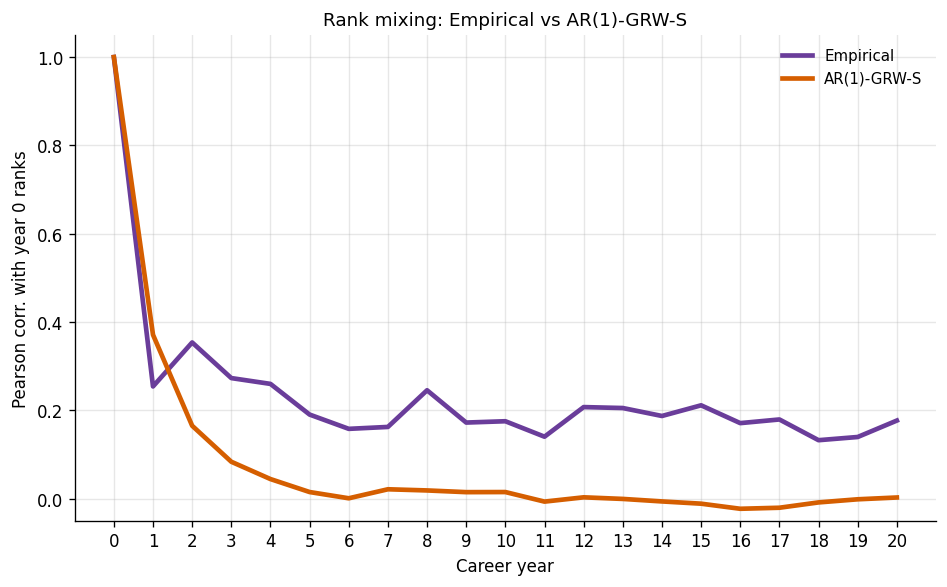

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

for source, color, label, zorder in [("empirical",EMP_COLOR,"Empirical",6),("simulated",SIM_COLOR,MODEL_NAME,7)]:
    subset = (rank_corr.loc[rank_corr["source"].eq(source)].sort_values("career_age"))

    ax.plot(subset["career_age"],subset["rank_correlation_with_year0"],color=color,linewidth=2.8,label=label,zorder=zorder)

ax.set_title(f"Rank mixing: Empirical vs {MODEL_NAME}")
ax.set_xlabel("Career year")
ax.set_ylabel("Pearson corr. with year 0 ranks")
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(YEARS)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()

save_figure(fig,"rankCorr")

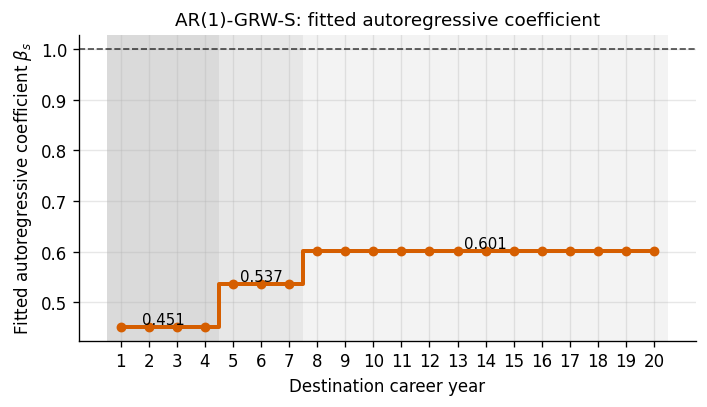

In [51]:
beta_by_year = []

for _, row in stage_params.iterrows():
    for year in range(int(row["start"]),int(row["end"]) + 1):
        beta_by_year.append({"destination_year": year,"stage": row["stage"],"beta": float(row["beta"])})

beta_by_year = pd.DataFrame(beta_by_year).sort_values("destination_year")

fig, ax = plt.subplots(figsize=(6, 3.5))

shade_stages(ax,transition_stage_spans)

ax.step(beta_by_year["destination_year"],beta_by_year["beta"],where="mid",color=SIM_COLOR,linewidth=2.4,zorder=3)

ax.scatter(beta_by_year["destination_year"],beta_by_year["beta"],color=SIM_COLOR,s=24,zorder=4)

ax.axhline(1,color="black",linestyle="--",linewidth=1,alpha=0.7)

for _, row in stage_params.iterrows():
    midpoint = (float(row["start"])+ float(row["end"])) / 2

    ax.text(midpoint,float(row["beta"]),f"{float(row['beta']):.3f}",ha="center",va="bottom",fontsize=9,zorder=5)

ax.set_xlabel("Destination career year")
ax.set_ylabel(r"Fitted autoregressive coefficient $\beta_s$")
ax.set_title(f"{MODEL_NAME}: fitted autoregressive coefficient")
ax.set_xticks(np.arange(1, Y + 1))
ax.grid(True, alpha=0.3)

fig.tight_layout()

save_figure(fig,"betaOverTime")